Saved PNG to ../data/ground/test1.png


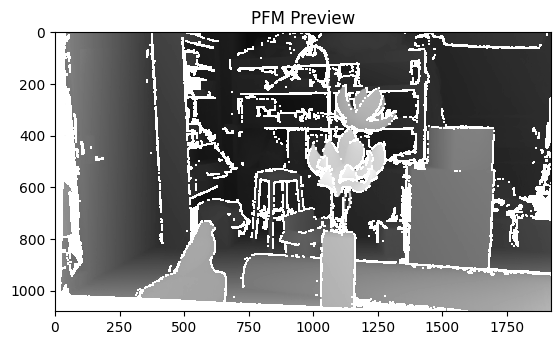

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def load_pfm(file):
    with open(file, 'rb') as f:
        header = f.readline().decode('utf-8').rstrip()
        color = header == 'PF'
        if header not in ['PF', 'Pf']:
            raise Exception('Not a PFM file.')

        dims = f.readline().decode('utf-8')
        while dims.startswith('#'):
            dims = f.readline().decode('utf-8')
        width, height = map(int, dims.strip().split())
        scale = float(f.readline().decode('utf-8').strip())
        endian = '<' if scale < 0 else '>'
        data = np.fromfile(f, endian + 'f')
        shape = (height, width, 3) if color else (height, width)
        data = np.reshape(data, shape)
        data = np.flipud(data)
        return data


def save_as_png(data, out_path):
    # 处理无效值
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    # 只保留正数（深度为0或负数通常为无效点）
    valid = data > 0
    min_val = np.min(data[valid]) if np.any(valid) else 0
    max_val = np.max(data[valid]) if np.any(valid) else 1

    # 归一化到0-1
    norm = np.zeros_like(data, dtype=np.float32)
    if max_val > min_val:
        norm[valid] = (data[valid] - min_val) / (max_val - min_val)
    # 反转：近处亮，远处暗
    norm[valid] = 1.0 - norm[valid]

    # 映射到0-255
    norm = (norm * 255).astype(np.uint8)
    cv2.imwrite(out_path, norm)
    print(f"Saved PNG to {out_path}")

if __name__ == '__main__':
    pfm_path = '../data/ground/test1.pfm'   # 替换为你的pfm文件路径
    png_path = '../data/ground/test1.png'      # 输出PNG路径

    data = load_pfm(pfm_path)
    save_as_png(data, png_path)

    # 可选：用matplotlib显示
    plt.figure()
    if data.ndim == 2:
        plt.imshow(data, cmap='gray')
    else:
        plt.imshow(data / np.max(data))
    plt.title('PFM Preview')
    plt.show()